# Data viewer — k-space / FT image / sensitivity map / RSS

For each sample (knee or brain) show one row:
**k-space (log magnitude)**, **FT coil image**, **sensitivity map**, **SENSE recon (FT)**, **RSS**.

Reads the per-slice dataset `data/{tissue}/{split}/*.h5` (built by `../MakeDataset.py`);
if that folder is empty it falls back to the aggregated `*_multicoil_train_*.h5` files.
Change `TISSUE`, `SPLIT`, `N_SAMPLES`, `COIL` below.

In [40]:
import os, glob
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('grayscale')

# ---------------- config ----------------
DATA_ROOT = '/mnt/d/research/MRRecon/data'   # per-slice dataset (after MakeDataset.py)
AGG_ROOT  = '/mnt/d/research/MRRecon'         # fallback: aggregated *_multicoil_train_*.h5
TISSUE    = 'brain'     # 'knee' | 'brain'
SPLIT     = 'train'    # 'train' | 'val' | 'test'
N_SAMPLES = 2          # number of samples (rows) to display
COIL      = 7          # coil index shown for k-space / FT / sensitivity panels
SEED      = None       # int -> reproducible random pick; None -> different samples each run

In [41]:
# ---------------- helpers ----------------
def ifft2c(x):
    """Centered orthonormal inverse FFT (fastMRI convention). x: (...,H,W) complex."""
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(x, axes=(-2, -1)), axes=(-2, -1), norm='ortho'),
        axes=(-2, -1))

def sense_combine(kspace, sens):           # (C,H,W) -> (H,W) complex
    return np.sum(np.conj(sens) * ifft2c(kspace), axis=0)

def rss_image(kspace):                     # (C,H,W) -> (H,W) real
    return np.sqrt((np.abs(ifft2c(kspace)) ** 2).sum(0))

def get_samples(n, seed=None):
    """Return list of (kspace, sens, rss|None, name) for n RANDOM samples."""
    rng = np.random.default_rng(seed)
    out = []
    d = os.path.join(DATA_ROOT, TISSUE, SPLIT)
    files = sorted(glob.glob(os.path.join(d, '*.h5')))
    if files:                              # per-slice dataset: random files
        pick = sorted(rng.choice(len(files), size=min(n, len(files)), replace=False))
        for idx in pick:
            with h5.File(files[idx], 'r') as f:
                k = f['kspace'][:]; s = f['sens_map'][:]
                r = f['rss'][:] if 'rss' in f else None
            out.append((k, s, r, os.path.basename(files[idx])))
    else:                                  # fallback: aggregated files, random slices
        kp = os.path.join(AGG_ROOT, f'{TISSUE}_multicoil_train_kspace.h5')
        sp = os.path.join(AGG_ROOT, f'{TISSUE}_multicoil_train_sens_map.h5')
        with h5.File(kp, 'r') as fk, h5.File(sp, 'r') as fs:
            ns = fk['kspace'].shape[0]
            pick = sorted(rng.choice(ns, size=min(n, ns), replace=False))
            for i in pick:
                out.append((fk['kspace'][i], fs['sens_maps'][i], None, f'agg[{i}]'))
    return out

# re-run this cell (with SEED=None) to draw a new random set of samples
samples = get_samples(N_SAMPLES, seed=SEED)
print(f'{TISSUE}/{SPLIT}: {len(samples)} random samples | '
      f'names = {[s[3] for s in samples]}')


brain/train: 2 random samples | names = ['file_brain_AXT1PRE_203_6000779_009.h5', 'file_brain_AXT1_201_6002836_009.h5']


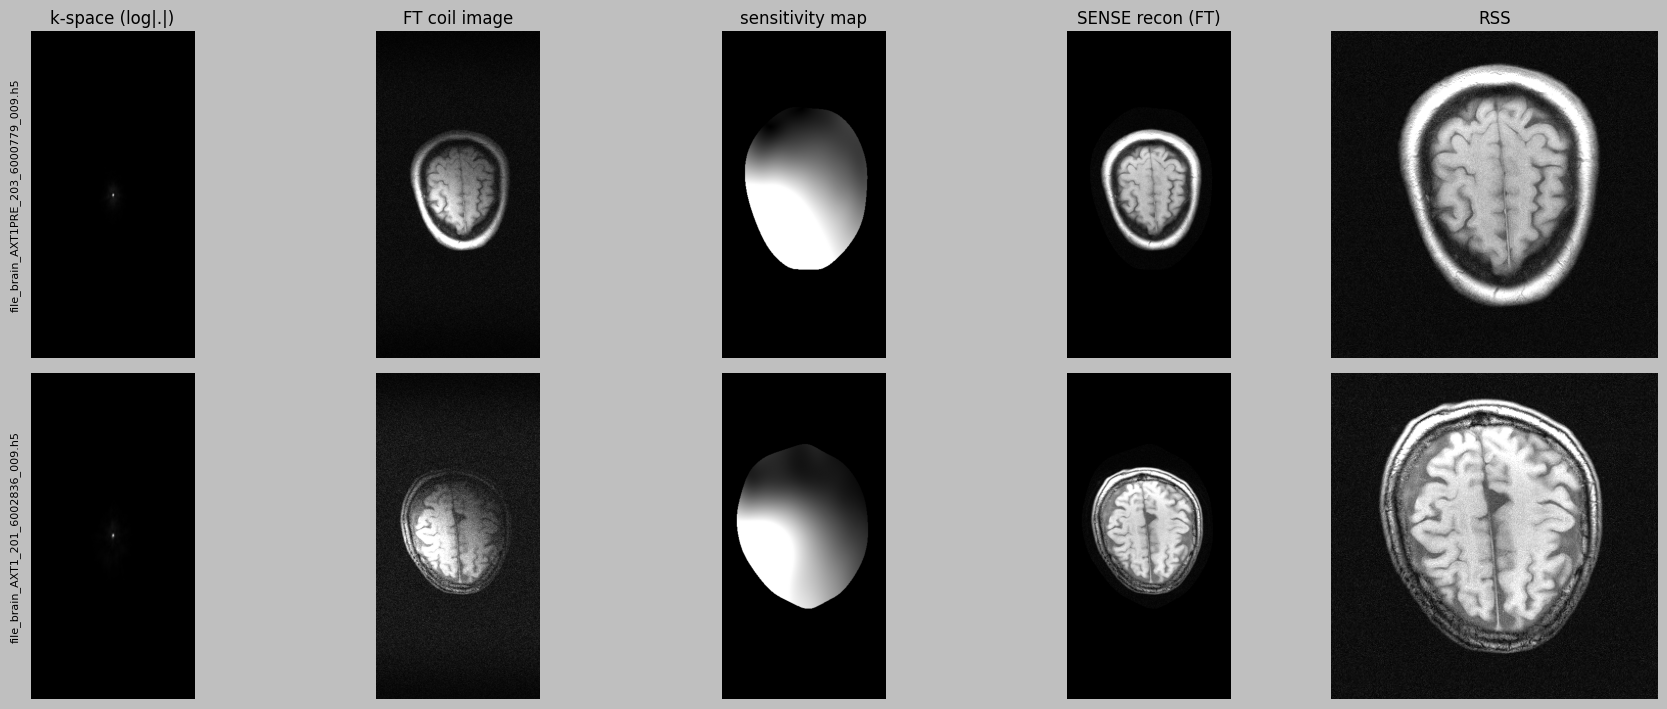

In [42]:
# ---------------- visualise ----------------
titles = ['k-space (log|.|)', 'FT coil image', 'sensitivity map',
          'SENSE recon (FT)', 'RSS']
fig, axes = plt.subplots(len(samples), 5, figsize=(18, 3.6 * len(samples)))
if len(samples) == 1:
    axes = axes[None, :]

for r, (k, s, rss, name) in enumerate(samples):
    c = min(COIL, k.shape[0] - 1)
    panels = [
        np.log1p(np.sqrt((np.abs(k) ** 2).sum(0))),   # coil-combined k-space (log)
        np.abs(ifft2c(k[c])),                          # single-coil FT image
        np.abs(s[c]),                                  # sensitivity map (one coil)
        np.abs(sense_combine(k, s)),                   # SENSE coil-combined recon
        np.abs(rss) if rss is not None else rss_image(k),  # RSS reference
    ]
    for col, (ax, im) in enumerate(zip(axes[r], panels)):
        vmax = None if col == 0 else 0.6 * im.max()
        ax.imshow(im, cmap='gray', vmax=vmax)
        ax.axis('off')
        if r == 0:
            ax.set_title(titles[col])
    axes[r, 0].text(-0.06, 0.5, name, transform=axes[r, 0].transAxes,
                    rotation=90, va='center', ha='right', fontsize=8)

plt.tight_layout()
plt.show()

file1000089_019.h5 | coils: 15


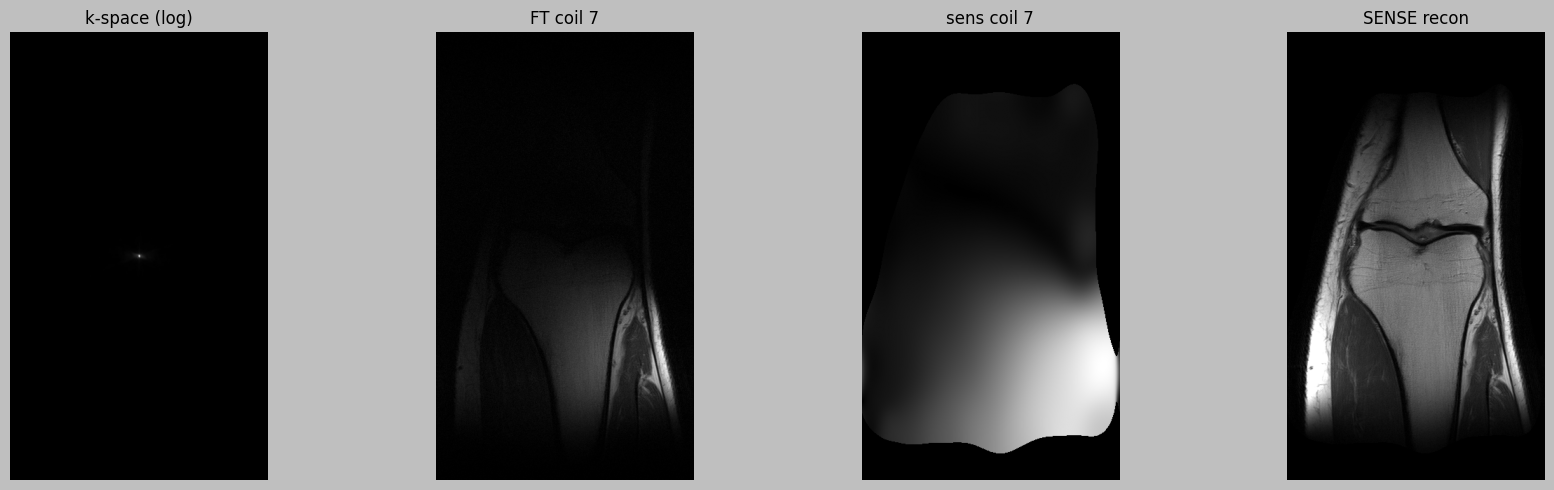

In [29]:
# ---------------- single sample, larger ----------------
# Inspect one sample in detail; change the index.
IDX = 0
k, s, rss, name = samples[IDX]
c = min(COIL, k.shape[0] - 1)
print(name, '| coils:', k.shape[0])

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(np.log1p(np.sqrt((np.abs(k) ** 2).sum(0))), cmap='gray'); ax[0].set_title('k-space (log)')
ax[1].imshow(np.abs(ifft2c(k[c])), cmap='gray'); ax[1].set_title(f'FT coil {c}')
ax[2].imshow(np.abs(s[c]), cmap='gray'); ax[2].set_title(f'sens coil {c}')
recon = np.abs(sense_combine(k, s)); ax[3].imshow(recon, cmap='gray', vmax=0.6*recon.max()); ax[3].set_title('SENSE recon')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 원본 fastMRI `.h5` 보기 — 전체 슬라이스 (k-space + RSS)

가공 전 멀티코일 원본 파일(`{tissue}_multicoil_train/*.h5`) 하나의 **모든 슬라이스**를
k-space 몽타주와 RSS 몽타주로 표시합니다. (`ifft2c`는 위 helpers 셀에서 정의)

file_brain_AXFLAIR_200_6002469.h5 | kspace (16, 16, 640, 320) | rss (16, 320, 320)


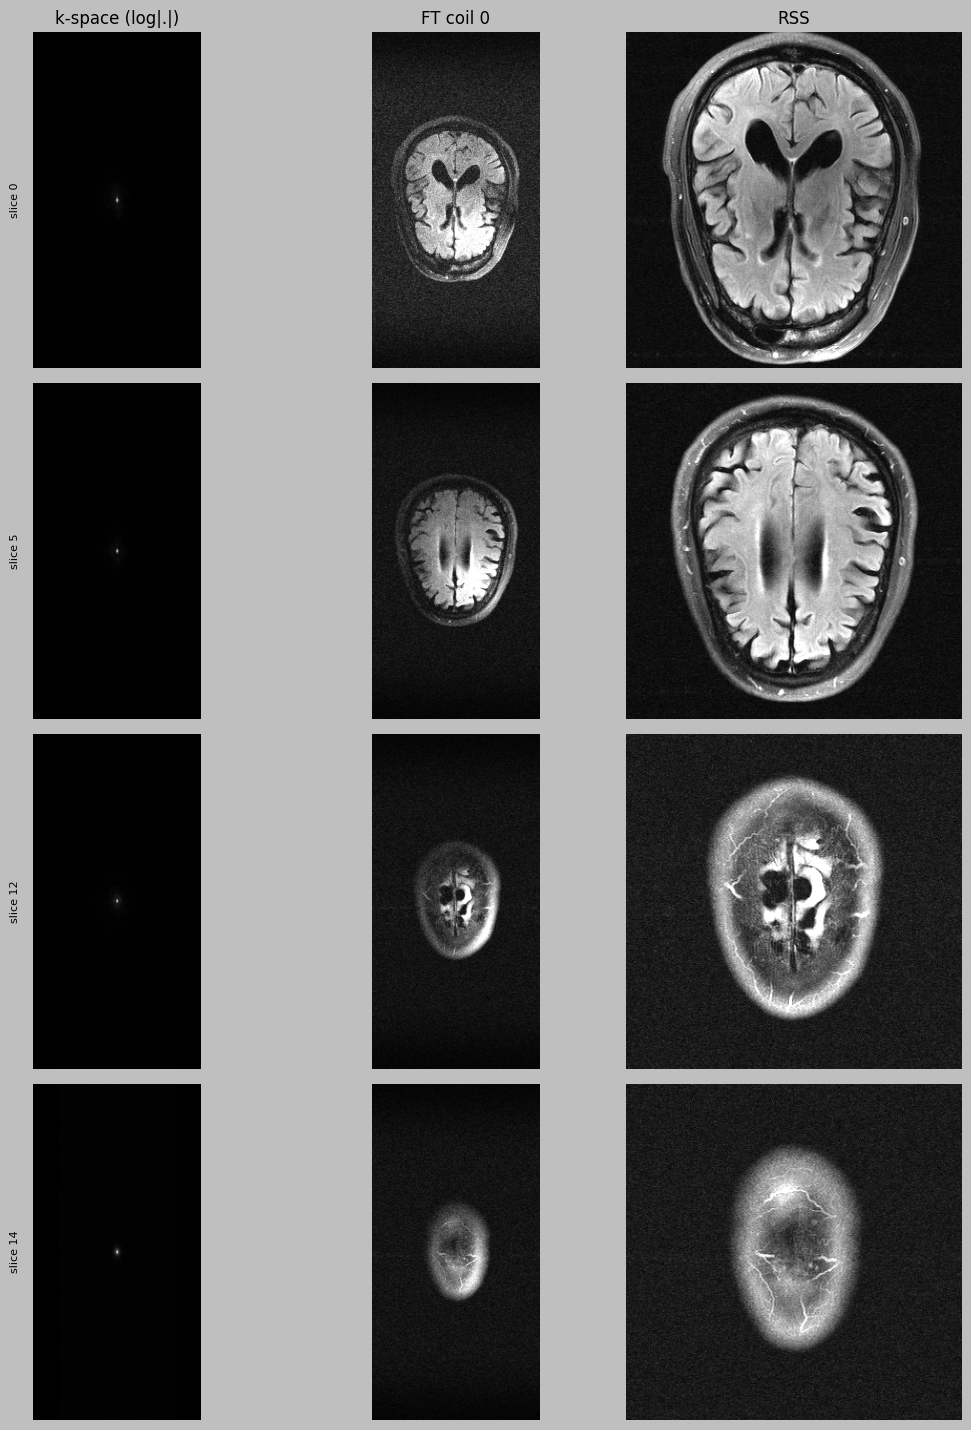

In [7]:
# ---------------- 원본 fastMRI .h5 뷰어 (전체 슬라이스) ----------------
RAW_MULTICOIL = {
    'knee':  '/mnt/d/research/MRRecon/knee_multicoil_train',
    'brain': '/mnt/d/research/MRRecon/brain_multicoil_train',
}

def _montage(vol, title, ncols=8, vmax_frac=0.6):
    """(S, H, W) 볼륨의 모든 슬라이스를 격자로 표시."""
    S = vol.shape[0]
    nrows = int(np.ceil(S / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=(1.8 * ncols, 1.8 * nrows))
    ax = np.atleast_2d(ax)
    for i in range(nrows * ncols):
        a = ax.flat[i]; a.axis('off')
        if i < S:
            im = vol[i]
            a.imshow(im, cmap='gray', vmax=(vmax_frac * im.max()) if im.max() > 0 else None)
            a.set_title(str(i), fontsize=7)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

def view_raw(fname=None, seed=None, ncols=8):
    """원본 멀티코일 파일 1개의 '전체 슬라이스'를 k-space / RSS 몽타주로 표시.

    fname=None 이면 TISSUE 폴더에서 무작위 파일 선택(재실행 시 새 파일).
    fname='file1000001.h5' 처럼 지정하면 해당 파일을 봄.
    """
    rng = np.random.default_rng(seed)
    d = RAW_MULTICOIL[TISSUE]
    files = sorted(glob.glob(os.path.join(d, '*.h5')))
    fp = os.path.join(d, fname) if fname else files[int(rng.integers(len(files)))]
    with h5.File(fp, 'r') as f:
        kspace = f['kspace'][:]                  # (S, C, H, W) complex
        rss = f['reconstruction_rss'][:]         # (S, h, w)
    name = os.path.basename(fp)
    print(f'{name} | slices={kspace.shape[0]} | kspace {kspace.shape} | rss {rss.shape}')

    kvol = np.log1p(np.sqrt((np.abs(kspace) ** 2).sum(1)))  # (S,H,W) coil-combined log k-space
    _montage(kvol, f'{name}  —  k-space (log|.|), all {kvol.shape[0]} slices', ncols)
    _montage(np.abs(rss), f'{name}  —  RSS, all {rss.shape[0]} slices', ncols)

# 무작위 파일의 전체 슬라이스. fname='file...' 로 특정 파일, ncols 로 열 수 조절.
view_raw(seed=None, ncols=8)

## RSS QC — 전체 데이터 RSS를 PNG로 저장

train/val/test 모든 슬라이스의 **RSS**만 PNG로 저장해 잘못된 데이터가 있는지 눈으로 확인합니다.
- 개별 PNG: `data/{tissue}/{split}/rss_png/{파일명}.png`
- 빠른 점검용 목타주 1장: `data/{tissue}/{split}_rss_montage.png`

In [31]:
# ---------------- RSS QC export (train/val/test) ----------------
QC_TISSUES = ['brain']      # ['knee', 'brain'] 로 두면 둘 다 처리
QC_NCOLS   = 12            # 몽타주 열 수

def _rss_of(fp):
    """파일의 RSS magnitude. rss 키가 없으면 k-space로부터 계산."""
    with h5.File(fp, 'r') as f:
        if 'rss' in f:
            return np.abs(f['rss'][:])
        return rss_image(f['kspace'][:])

def export_rss_pngs(tissue, splits=('train', 'val', 'test')):
    """각 슬라이스 RSS를 개별 PNG로 {split}/rss_png/ 에 저장."""
    for split in splits:
        d = os.path.join(DATA_ROOT, tissue, split)
        files = sorted(glob.glob(os.path.join(d, '*.h5')))
        if not files:
            print(f'{tissue}/{split}: (no files)'); continue
        outdir = os.path.join(d, 'rss_png'); os.makedirs(outdir, exist_ok=True)
        for fp in files:
            img = _rss_of(fp)
            name = os.path.splitext(os.path.basename(fp))[0]
            plt.imsave(os.path.join(outdir, name + '.png'), img, cmap='gray',
                       vmax=0.6 * img.max() if img.max() > 0 else None)
        print(f'{tissue}/{split}: saved {len(files)} PNGs -> {outdir}')

def save_rss_montage(tissue, split, ncols=12):
    """한 split 전체 RSS를 격자 1장 PNG로 저장 (빠른 점검용)."""
    d = os.path.join(DATA_ROOT, tissue, split)
    files = sorted(glob.glob(os.path.join(d, '*.h5')))
    if not files:
        print(f'{tissue}/{split}: (no files)'); return
    S = len(files); nrows = int(np.ceil(S / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=(1.3 * ncols, 1.3 * nrows))
    ax = np.atleast_2d(ax)
    for i in range(nrows * ncols):
        a = ax.flat[i]; a.axis('off')
        if i < S:
            img = _rss_of(files[i])
            a.imshow(img, cmap='gray', vmax=0.6 * img.max() if img.max() > 0 else None)
            a.set_title(os.path.basename(files[i])[:16], fontsize=4)
    out = os.path.join(DATA_ROOT, tissue, f'{split}_rss_montage.png')
    fig.suptitle(f'{tissue}/{split}  ({S} slices)')
    plt.tight_layout(); fig.savefig(out, dpi=130); plt.close(fig)
    print(f'{tissue}/{split}: montage -> {out}')

for t in QC_TISSUES:
    export_rss_pngs(t)                         # 개별 PNG (잘못된 파일 찾기)
    for sp in ('train', 'val', 'test'):
        save_rss_montage(t, sp, QC_NCOLS)      # split별 몽타주 1장 (한눈에 점검)

brain/train: saved 330 PNGs -> /mnt/d/research/MRRecon/data/brain/train/rss_png
brain/val: saved 45 PNGs -> /mnt/d/research/MRRecon/data/brain/val/rss_png
brain/test: saved 45 PNGs -> /mnt/d/research/MRRecon/data/brain/test/rss_png
brain/train: montage -> /mnt/d/research/MRRecon/data/brain/train_rss_montage.png
brain/val: montage -> /mnt/d/research/MRRecon/data/brain/val_rss_montage.png
brain/test: montage -> /mnt/d/research/MRRecon/data/brain/test_rss_montage.png


## 중앙 슬라이스 뷰어 (train/val/test)

subject당 **중앙 슬라이스 1장**만 골라 **k-space / sensitivity map / RSS / conjugate-sum(SENSE 결합)** 4개 패널로 표시.
(conjugate sum = `sum_c conj(S_c) * IFFT(kspace_c)`)

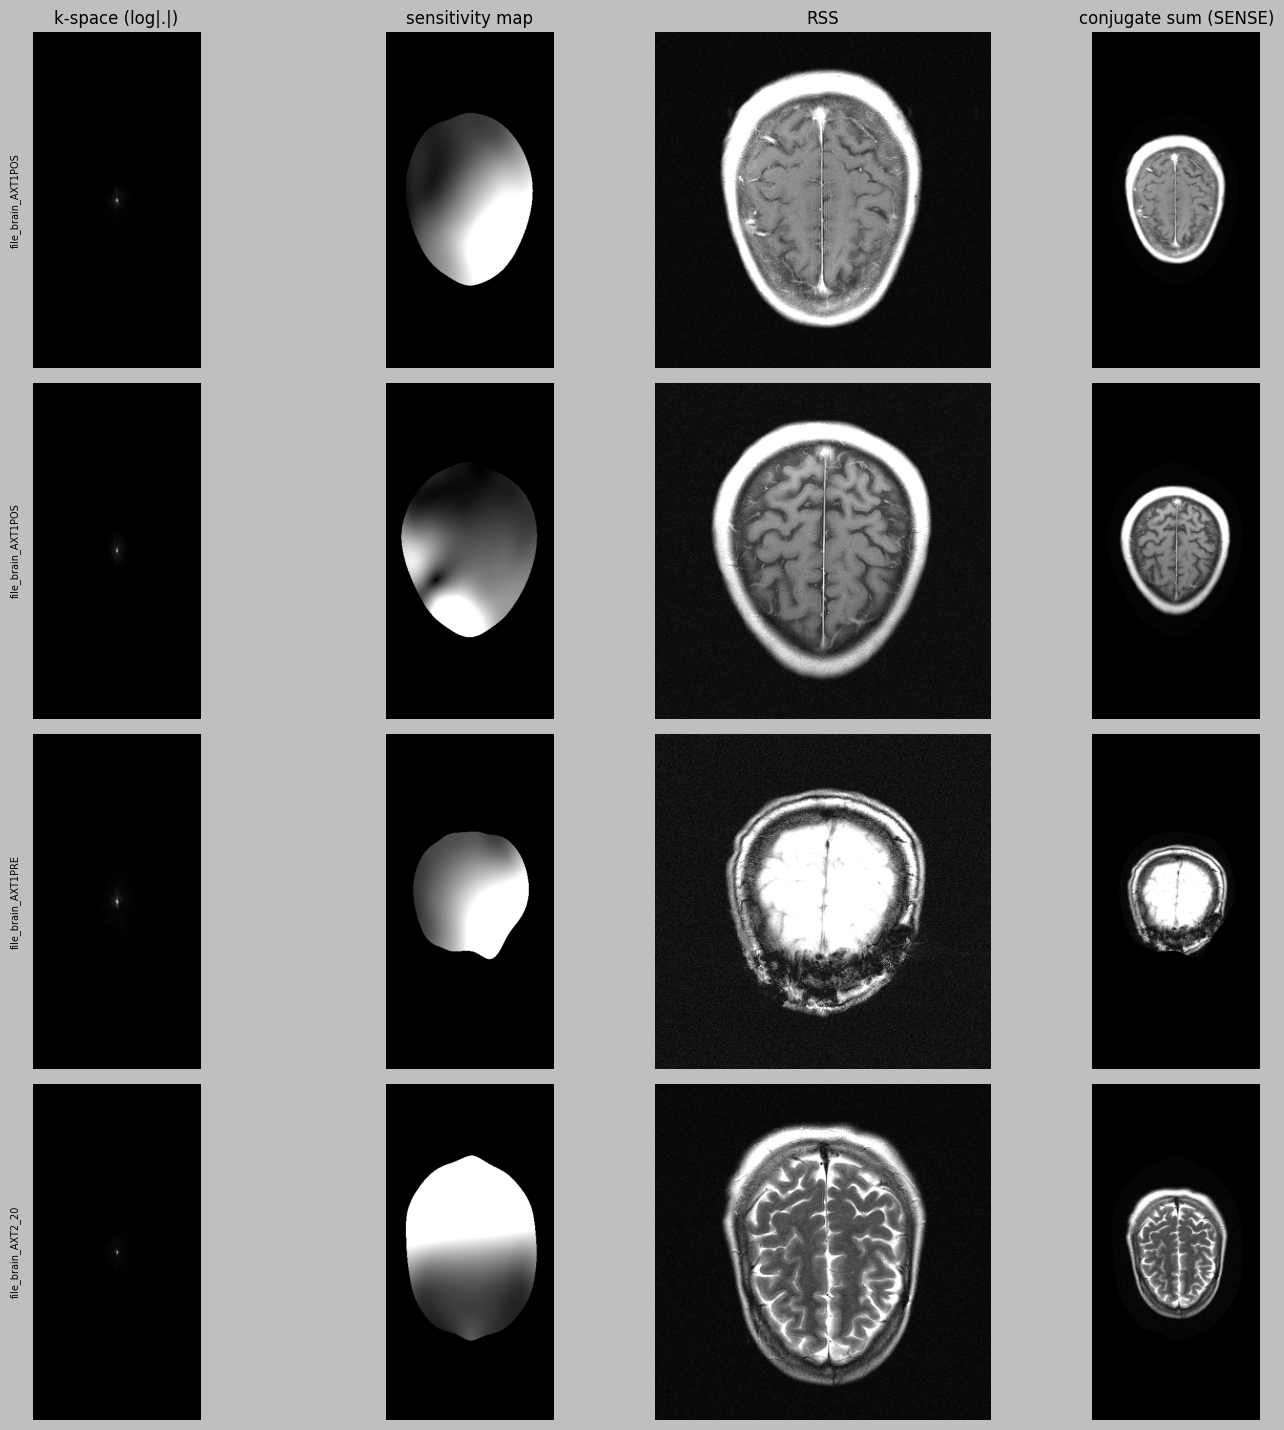

In [36]:
# ---------------- 중앙 슬라이스 뷰어 ----------------
import re

def center_files(tissue, split):
    """subject당 가운데 슬라이스 파일 1개 (저장된 3장 중 median index)."""
    files = sorted(glob.glob(os.path.join(DATA_ROOT, tissue, split, '*.h5')))
    bysubj = {}
    for fp in files:
        m = re.match(r'(.+)_(\d+)\.h5', os.path.basename(fp))
        if not m:
            continue
        bysubj.setdefault(m.group(1), []).append((int(m.group(2)), fp))
    centers = [sorted(v)[len(v) // 2][1] for v in bysubj.values()]
    return sorted(centers)

def kspace_db(k):
    """coil-combined k-space를 dB 로그 스케일로 (구조가 보이게)."""
    mag = np.sqrt((np.abs(k) ** 2).sum(0))
    return 20 * np.log10(mag / (mag.max() + 1e-12) + 1e-6)   # [-120, 0] dB

def view_center(tissue=None, split='train', n=4, seed=None, coil=0):
    """중앙 슬라이스 n개를 5개 패널로: k-space(dB) / coil 영상 / sens / RSS / SENSE."""
    tissue = tissue or TISSUE
    rng = np.random.default_rng(seed)
    files = center_files(tissue, split)
    if not files:
        print(f'{tissue}/{split}: no files'); return
    pick = sorted(rng.choice(len(files), size=min(n, len(files)), replace=False))
    titles = [f'k-space (log dB)', f'coil {coil} image', 'sensitivity map',
              'RSS', 'conjugate sum (SENSE)']
    fig, ax = plt.subplots(len(pick), 5, figsize=(18, 3.6 * len(pick)))
    if len(pick) == 1:
        ax = ax[None, :]
    for r, idx in enumerate(pick):
        with h5.File(files[idx], 'r') as f:
            k = f['kspace'][:]; s = f['sens_map'][:]
            rss = np.abs(f['rss'][:]) if 'rss' in f else rss_image(f['kspace'][:])
        c = min(coil, k.shape[0] - 1)
        panels = [kspace_db(k),                       # k-space (log dB)
                  np.abs(ifft2c(k[c])),               # single-coil image |IFFT(k_c)|
                  np.abs(s[c]),                       # sensitivity map (coil c)
                  rss,                                # RSS
                  np.abs(sense_combine(k, s))]        # conjugate-sum (SENSE)
        for col, (a, im) in enumerate(zip(ax[r], panels)):
            vmax = None if col == 0 else 0.6 * im.max()   # k-space: full dB range
            a.imshow(im, cmap='gray', vmax=vmax)
            a.axis('off')
            if r == 0:
                a.set_title(titles[col])
        ax[r, 0].text(-0.07, 0.5, os.path.basename(files[idx])[:18],
                      transform=ax[r, 0].transAxes, rotation=90, va='center',
                      ha='right', fontsize=7)
    plt.tight_layout(); plt.show()

view_center(split='train', n=4, seed=None, coil=0)